In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cleaned_data.csv")
df

,Unnamed: 0,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type
0,0,387,6.094781,7.423652,No,No,Yes,Roots and tubers
1,2,370,6.099892,7.418512,No,No,No,"Semi-luxury foods (coffee, tea, cocoa, tobacco..."
2,3,362,6.096048,7.417137,No,No,No,Roots and tubers
3,5,178,6.426840,7.346881,No,No,No,Fodder plants
4,7,128,5.609925,6.615464,No,No,No,Oilcrops
...,...,...,...,...,...,...,...,...
7751,13855,1180,-5.282243,31.366502,No,No,Yes,Fodder plants
7752,13856,1190,-5.280960,31.366483,No,No,Yes,Fruits
7753,13857,1188,-5.281934,31.367701,No,No,No,Fodder plants
7754,13864,879,-3.795245,33.273638,No,No,Yes,Fodder plants


In [3]:
df.drop(df.columns[0], axis = 1, inplace = True)
df

,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type
0,387,6.094781,7.423652,No,No,Yes,Roots and tubers
1,370,6.099892,7.418512,No,No,No,"Semi-luxury foods (coffee, tea, cocoa, tobacco..."
2,362,6.096048,7.417137,No,No,No,Roots and tubers
3,178,6.426840,7.346881,No,No,No,Fodder plants
4,128,5.609925,6.615464,No,No,No,Oilcrops
...,...,...,...,...,...,...,...
7751,1180,-5.282243,31.366502,No,No,Yes,Fodder plants
7752,1190,-5.280960,31.366483,No,No,Yes,Fruits
7753,1188,-5.281934,31.367701,No,No,No,Fodder plants
7754,879,-3.795245,33.273638,No,No,Yes,Fodder plants


In [4]:
from sklearn.cluster import KMeans

In [5]:
coords = df[['longitude', 'latitude']]
wcss = []
k_range = range(1, 11)

In [6]:
for k in k_range:
    kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state = 42, n_init = 10)
    kmeans.fit(coords)
    wcss.append(kmeans.inertia_)

In [7]:
wcss

[3878662.4907204346,
 1148267.7542247004,
 816699.0336768834,
 573851.707575937,
 452481.63026972534,
 350302.329654391,
 293388.05750204204,
 230768.37656869867,
 183981.1061522603,
 158348.10847175797]

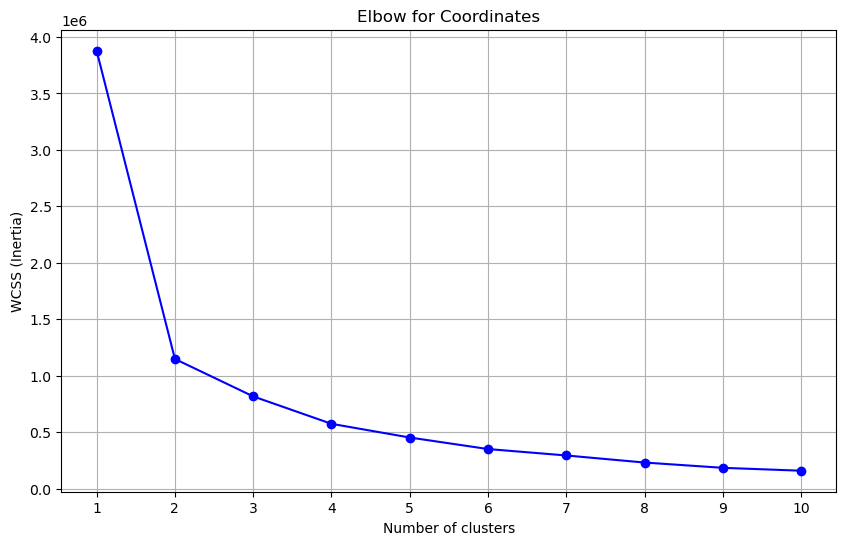

In [8]:
plt.figure(figsize = (10, 6))
plt.plot(k_range, wcss, marker = 'o', linestyle = '-', color = 'b')
plt.title('Elbow for Coordinates')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Inertia)') #Measure of how 'close' points are
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [9]:
#K-Nearest Neighbor to group outliers to the nearest neighbors
from sklearn.neighbors import KNeighborsClassifier

In [10]:
#Applying DBSCAN
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps = 1.5, min_samples = 15)
cluster_labels = dbscan.fit_predict(coords)

In [11]:
valid_data = coords[cluster_labels != -1]
valid_labels = cluster_labels[cluster_labels != -1]
noise_data = coords[cluster_labels == -1]

In [12]:
knn = KNeighborsClassifier(n_neighbors = 1)
knn.fit(valid_data, valid_labels)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [13]:
noise_labels = knn.predict(noise_data)
noise_labels

array([ 2,  3,  2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,  3,  2,  5,  5,
        2,  2,  2,  2,  2,  2,  2,  2,  9,  9,  9,  9,  5,  5,  5,  5,  5,
        5,  5,  5, 11,  5,  6,  5,  5,  2, 16, 16, 16,  2,  2,  2,  2, 11,
        7,  7,  7,  7, 13, 13, 13, 13, 13, 13, 13, 13,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  8, 16, 16, 16, 16, 16, 16, 16, 16, 10, 10, 10],
      dtype=int64)

In [14]:
cluster_labels[cluster_labels == -1] = noise_labels

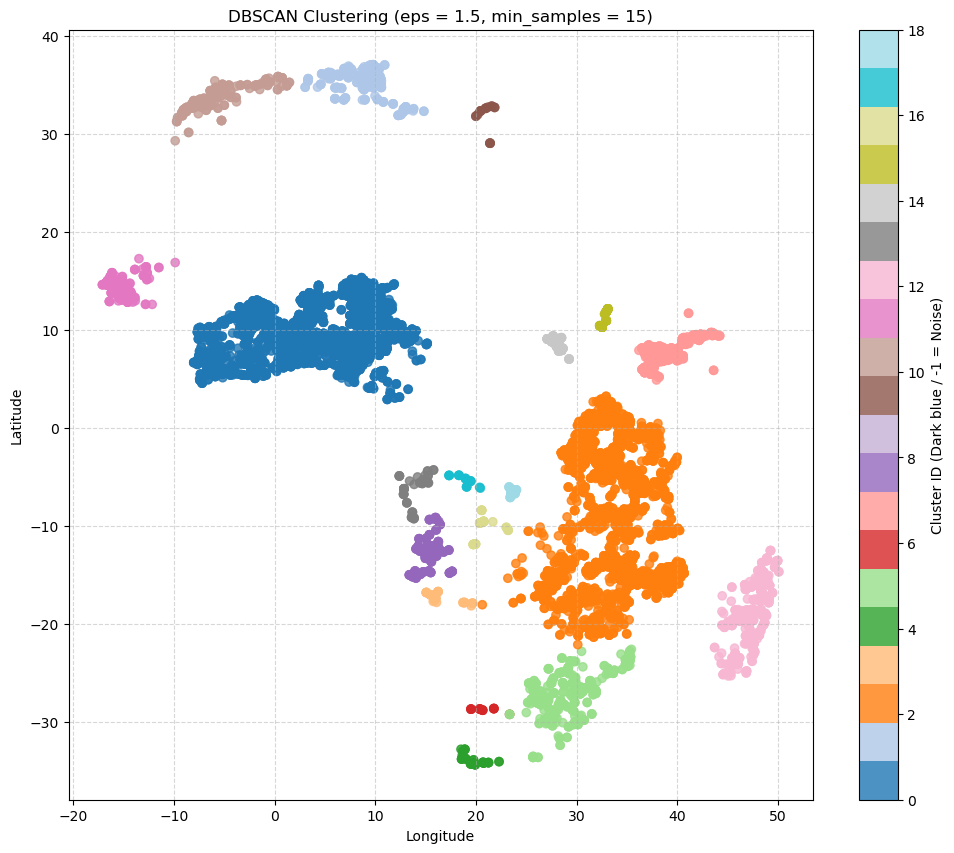

In [15]:
plt.figure(figsize = (12, 10))
scatter = plt.scatter(df['longitude'], df['latitude'], c = cluster_labels, cmap = 'tab20', alpha = 0.8)
plt.title(f'DBSCAN Clustering (eps = {dbscan.eps}, min_samples = {dbscan.min_samples})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(scatter, label = 'Cluster ID (Dark blue / -1 = Noise)')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.savefig('clusters_before_knn.png')
plt.show()

In [16]:
print(cluster_labels)
len(cluster_labels)

[ 0  0  0 ... 10 10  8]


7756

In [17]:
distinct_clusters = np.unique(cluster_labels)
print(distinct_clusters)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]


In [18]:
#Saving KNN Model
%pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [19]:
import joblib
joblib.dump(knn, 'knn_spatial_mapper.pkl')

['knn_spatial_mapper.pkl']

In [20]:
#One-Hot Encoding the coordinate data
df['geo_clusters'] = cluster_labels
df

,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type,geo_clusters
0,387,6.094781,7.423652,No,No,Yes,Roots and tubers,0
1,370,6.099892,7.418512,No,No,No,"Semi-luxury foods (coffee, tea, cocoa, tobacco...",0
2,362,6.096048,7.417137,No,No,No,Roots and tubers,0
3,178,6.426840,7.346881,No,No,No,Fodder plants,0
4,128,5.609925,6.615464,No,No,No,Oilcrops,0
...,...,...,...,...,...,...,...,...
7751,1180,-5.282243,31.366502,No,No,Yes,Fodder plants,10
7752,1190,-5.280960,31.366483,No,No,Yes,Fruits,10
7753,1188,-5.281934,31.367701,No,No,No,Fodder plants,10
7754,879,-3.795245,33.273638,No,No,Yes,Fodder plants,10


In [21]:
df_encoded = pd.get_dummies(df, columns = ['geo_clusters'], prefix = 'cluster')
df_encoded

,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type,cluster_0,cluster_1,cluster_2,...,cluster_9,cluster_10,cluster_11,cluster_12,cluster_13,cluster_14,cluster_15,cluster_16,cluster_17,cluster_18
0,387,6.094781,7.423652,No,No,Yes,Roots and tubers,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,370,6.099892,7.418512,No,No,No,"Semi-luxury foods (coffee, tea, cocoa, tobacco...",True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,362,6.096048,7.417137,No,No,No,Roots and tubers,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,178,6.426840,7.346881,No,No,No,Fodder plants,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,128,5.609925,6.615464,No,No,No,Oilcrops,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7751,1180,-5.282243,31.366502,No,No,Yes,Fodder plants,False,False,False,...,False,True,False,False,False,False,False,False,False,False
7752,1190,-5.280960,31.366483,No,No,Yes,Fruits,False,False,False,...,False,True,False,False,False,False,False,False,False,False
7753,1188,-5.281934,31.367701,No,No,No,Fodder plants,False,False,False,...,False,True,False,False,False,False,False,False,False,False
7754,879,-3.795245,33.273638,No,No,Yes,Fodder plants,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [22]:
df_encoded.drop(columns = ['longitude', 'latitude'], inplace = True)
df_encoded

,altitude,srf_salt,srf_crust,bare_soil,crop_type,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,...,cluster_9,cluster_10,cluster_11,cluster_12,cluster_13,cluster_14,cluster_15,cluster_16,cluster_17,cluster_18
0,387,No,No,Yes,Roots and tubers,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,370,No,No,No,"Semi-luxury foods (coffee, tea, cocoa, tobacco...",True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,362,No,No,No,Roots and tubers,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,178,No,No,No,Fodder plants,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,128,No,No,No,Oilcrops,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7751,1180,No,No,Yes,Fodder plants,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
7752,1190,No,No,Yes,Fruits,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
7753,1188,No,No,No,Fodder plants,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
7754,879,No,No,Yes,Fodder plants,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [23]:
df

,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type,geo_clusters
0,387,6.094781,7.423652,No,No,Yes,Roots and tubers,0
1,370,6.099892,7.418512,No,No,No,"Semi-luxury foods (coffee, tea, cocoa, tobacco...",0
2,362,6.096048,7.417137,No,No,No,Roots and tubers,0
3,178,6.426840,7.346881,No,No,No,Fodder plants,0
4,128,5.609925,6.615464,No,No,No,Oilcrops,0
...,...,...,...,...,...,...,...,...
7751,1180,-5.282243,31.366502,No,No,Yes,Fodder plants,10
7752,1190,-5.280960,31.366483,No,No,Yes,Fruits,10
7753,1188,-5.281934,31.367701,No,No,No,Fodder plants,10
7754,879,-3.795245,33.273638,No,No,Yes,Fodder plants,10


In [24]:
#OHE
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore')
encoder.fit(df[['geo_clusters']])

joblib.dump(encoder, 'cluster_encoder.pkl')

['cluster_encoder.pkl']

In [25]:
#Standard scaler for altitude
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['scaled_altitude'] = scaler.fit_transform(df[['altitude']])

joblib.dump(scaler, 'altitude_scaler.pkl')

['altitude_scaler.pkl']

In [26]:
#Mapping the Yes/No columns
binary_map = {'Yes' : 1, 'No' : 0}
df['srf_salt'] = df['srf_salt'].map(binary_map)
df['srf_crust'] = df['srf_crust'].map(binary_map)
df['bare_soil'] = df['bare_soil'].map(binary_map)
df

,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type,geo_clusters,scaled_altitude
0,387,6.094781,7.423652,0,0,1,Roots and tubers,0,-0.569947
1,370,6.099892,7.418512,0,0,0,"Semi-luxury foods (coffee, tea, cocoa, tobacco...",0,-0.598111
2,362,6.096048,7.417137,0,0,0,Roots and tubers,0,-0.611364
3,178,6.426840,7.346881,0,0,0,Fodder plants,0,-0.916195
4,128,5.609925,6.615464,0,0,0,Oilcrops,0,-0.999030
...,...,...,...,...,...,...,...,...,...
7751,1180,-5.282243,31.366502,0,0,1,Fodder plants,10,0.743808
7752,1190,-5.280960,31.366483,0,0,1,Fruits,10,0.760375
7753,1188,-5.281934,31.367701,0,0,0,Fodder plants,10,0.757061
7754,879,-3.795245,33.273638,0,0,1,Fodder plants,10,0.245144


In [27]:
#Label encoding target variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit_transform(df['crop_type'])

joblib.dump(le, 'prediction_label_encoder.pkl')

['prediction_label_encoder.pkl']

In [28]:
df['crops'] = le.transform(df['crop_type'])
df

,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type,geo_clusters,scaled_altitude,crops
0,387,6.094781,7.423652,0,0,1,Roots and tubers,0,-0.569947,8
1,370,6.099892,7.418512,0,0,0,"Semi-luxury foods (coffee, tea, cocoa, tobacco...",0,-0.598111,9
2,362,6.096048,7.417137,0,0,0,Roots and tubers,0,-0.611364,8
3,178,6.426840,7.346881,0,0,0,Fodder plants,0,-0.916195,2
4,128,5.609925,6.615464,0,0,0,Oilcrops,0,-0.999030,5
...,...,...,...,...,...,...,...,...,...,...
7751,1180,-5.282243,31.366502,0,0,1,Fodder plants,10,0.743808,2
7752,1190,-5.280960,31.366483,0,0,1,Fruits,10,0.760375,3
7753,1188,-5.281934,31.367701,0,0,0,Fodder plants,10,0.757061,2
7754,879,-3.795245,33.273638,0,0,1,Fodder plants,10,0.245144,2


In [29]:
df['crop_type'].value_counts()

crop_type
Cereals                                                  4791
Roots and tubers                                          828
Pulses                                                    412
Semi-luxury foods (coffee, tea, cocoa, tobacco, nuts)     405
Oilcrops                                                  368
Fruits                                                    304
Other crops (e.g., rubber)                                216
Fibre crops                                               172
Fodder plants                                             155
Vegetables                                                 91
Nursery stock                                              14
Name: count, dtype: int64

In [31]:
df_final = df.copy()
df_final

,altitude,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type,geo_clusters,scaled_altitude,crops
0,387,6.094781,7.423652,0,0,1,Roots and tubers,0,-0.569947,8
1,370,6.099892,7.418512,0,0,0,"Semi-luxury foods (coffee, tea, cocoa, tobacco...",0,-0.598111,9
2,362,6.096048,7.417137,0,0,0,Roots and tubers,0,-0.611364,8
3,178,6.426840,7.346881,0,0,0,Fodder plants,0,-0.916195,2
4,128,5.609925,6.615464,0,0,0,Oilcrops,0,-0.999030,5
...,...,...,...,...,...,...,...,...,...,...
7751,1180,-5.282243,31.366502,0,0,1,Fodder plants,10,0.743808,2
7752,1190,-5.280960,31.366483,0,0,1,Fruits,10,0.760375,3
7753,1188,-5.281934,31.367701,0,0,0,Fodder plants,10,0.757061,2
7754,879,-3.795245,33.273638,0,0,1,Fodder plants,10,0.245144,2


In [37]:
df_final.drop(columns = ['altitude'], inplace = True)
df_final

,longitude,latitude,srf_salt,srf_crust,bare_soil,crop_type,geo_clusters,scaled_altitude,crops
0,6.094781,7.423652,0,0,1,Roots and tubers,0,-0.569947,8
1,6.099892,7.418512,0,0,0,"Semi-luxury foods (coffee, tea, cocoa, tobacco...",0,-0.598111,9
2,6.096048,7.417137,0,0,0,Roots and tubers,0,-0.611364,8
3,6.426840,7.346881,0,0,0,Fodder plants,0,-0.916195,2
4,5.609925,6.615464,0,0,0,Oilcrops,0,-0.999030,5
...,...,...,...,...,...,...,...,...,...
7751,-5.282243,31.366502,0,0,1,Fodder plants,10,0.743808,2
7752,-5.280960,31.366483,0,0,1,Fruits,10,0.760375,3
7753,-5.281934,31.367701,0,0,0,Fodder plants,10,0.757061,2
7754,-3.795245,33.273638,0,0,1,Fodder plants,10,0.245144,2


In [48]:
x = df_final.iloc[:,:5]
y = df_final['crop_type']

In [51]:
x = x.join(df_final['geo_clusters'])
x

,longitude,latitude,srf_salt,srf_crust,bare_soil,geo_clusters
0,6.094781,7.423652,0,0,1,0
1,6.099892,7.418512,0,0,0,0
2,6.096048,7.417137,0,0,0,0
3,6.426840,7.346881,0,0,0,0
4,5.609925,6.615464,0,0,0,0
...,...,...,...,...,...,...
7751,-5.282243,31.366502,0,0,1,10
7752,-5.280960,31.366483,0,0,1,10
7753,-5.281934,31.367701,0,0,0,10
7754,-3.795245,33.273638,0,0,1,10


In [52]:
y = le.transform(df_final['crop_type'])
y

array([8, 9, 8, ..., 2, 2, 0])

In [53]:
df_final['crop_type'].value_counts()

crop_type
Cereals                                                  4791
Roots and tubers                                          828
Pulses                                                    412
Semi-luxury foods (coffee, tea, cocoa, tobacco, nuts)     405
Oilcrops                                                  368
Fruits                                                    304
Other crops (e.g., rubber)                                216
Fibre crops                                               172
Fodder plants                                             155
Vegetables                                                 91
Nursery stock                                              14
Name: count, dtype: int64

In [55]:
features = ['Cereals', 'Roots and tubers', 'Pulses', 'Semi-luxury foods (coffee, tea, cocoa, tobacco, nuts)', 'Oilcrops', 'Fruits', 'Fibre crops', 'Fodder plants']
df_final['crop_type'] = df_final['crop_type'].where(df_final['crop_type'].isin(features), 'Others')
df_final['crop_type'].value_counts()

crop_type
Cereals                                                  4791
Roots and tubers                                          828
Pulses                                                    412
Semi-luxury foods (coffee, tea, cocoa, tobacco, nuts)     405
Oilcrops                                                  368
Others                                                    321
Fruits                                                    304
Fibre crops                                               172
Fodder plants                                             155
Name: count, dtype: int64

In [61]:
y = None
y = le.fit_transform(df_final['crop_type'])
y

array([7, 8, 7, ..., 2, 2, 0])

In [62]:
joblib.dump(le, 'prediction_label_encoder.pkl')

['prediction_label_encoder.pkl']